# 05 — Model Comparison
### Forecasting model comparison - LSTM vs GRU vs TFT vs FAG-TFT

In [4]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load all model results
results = []
for fname, label in [
    ('forecast_lstm_results.pkl', 'LSTM Forecaster (Baseline 1)'),
    ('forecast_gru_results.pkl',  'GRU Forecaster (Baseline 2)'),
    ('tft_binary_results.pkl',    'TFT Forecaster (Proposed)'),
    ('fag_tft_results.pkl',       'FAG-TFT Classifier (Proposed)'),
]:
    with open(fname,'rb') as f: r = pickle.load(f)
    r['model'] = label
    results.append(r)

df = pd.DataFrame(results)[['model','accuracy','f1','rmse','mae']]
df['accuracy_pct'] = (df['accuracy'] * 100).round(2)
df['f1']   = df['f1'].round(4)
df['rmse'] = df['rmse'].round(4)
df['mae']  = df['mae'].round(4)

display_df = df[['model','accuracy_pct','f1','rmse','mae']].copy()
display_df.columns = ['Model', 'Accuracy (%)', 'F1 Score', 'RMSE', 'MAE']
print('='*70)
print('ALL MODEL COMPARISON')
print('='*70)
print(display_df.to_string(index=False))
print()
best_idx = df['f1'].idxmax()
print(f'Best Model (by F1): {display_df.iloc[best_idx]["Model"]}')
print()
print('Note: LSTM / GRU / TFT Forecasters = future breakdown prediction (binary).')
print('      FAG-TFT Classifier            = current breakdown type classification.')


ALL MODEL COMPARISON
                        Model  Accuracy (%)  F1 Score   RMSE    MAE
 LSTM Forecaster (Baseline 1)         94.92    0.9486 0.2253 0.0508
  GRU Forecaster (Baseline 2)         94.09    0.9408 0.2431 0.0591
    TFT Forecaster (Proposed)         96.13    0.9603 0.1968 0.0387
FAG-TFT Classifier (Proposed)         99.26    0.9928 0.1977 0.0158

Best Model (by F1): FAG-TFT Classifier (Proposed)

Note: LSTM / GRU / TFT Forecasters = future breakdown prediction (binary).
      FAG-TFT Classifier            = current breakdown type classification.


#### Comparison Charts


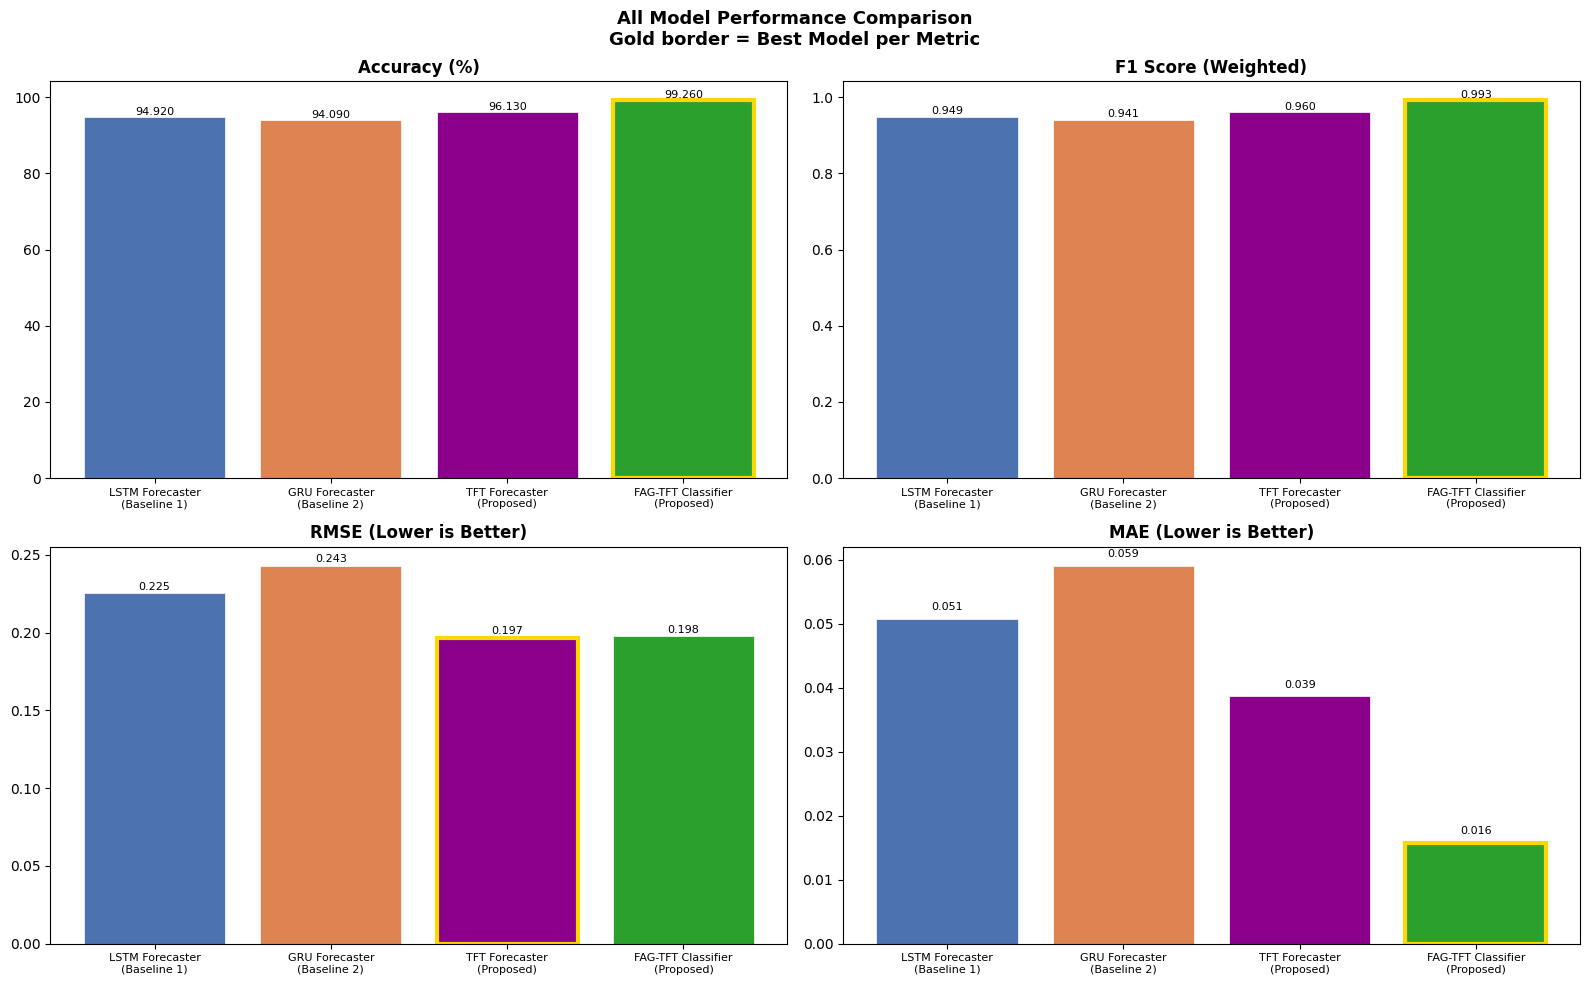

✅ Comparison chart saved.


In [5]:
models  = display_df['Model'].tolist()
colors  = ['#4C72B0', '#DD8452', '#8B008B', '#2ca02c']
x       = np.arange(len(models))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = [
    ('Accuracy (%)', 'Accuracy (%)', True),
    ('F1 Score',     'F1 Score (Weighted)', True),
    ('RMSE',         'RMSE (Lower is Better)', False),
    ('MAE',          'MAE (Lower is Better)', False),
]

for ax, (col, title, higher_better) in zip(axes.flat, metrics):
    vals = display_df[col].values
    bars = ax.bar(x, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' (', '\n(') for m in models], fontsize=8)
    ax.set_title(title, fontweight='bold')
    best = np.argmax(vals) if higher_better else np.argmin(vals)
    bars[best].set_edgecolor('gold')
    bars[best].set_linewidth(3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('All Model Performance Comparison\nGold border = Best Model per Metric',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison chart saved.')


#### Forecasters Only — Side-by-Side (01 vs 02 vs 03)
> Isolates the three models that share the same forecasting task for a fair apples-to-apples comparison.


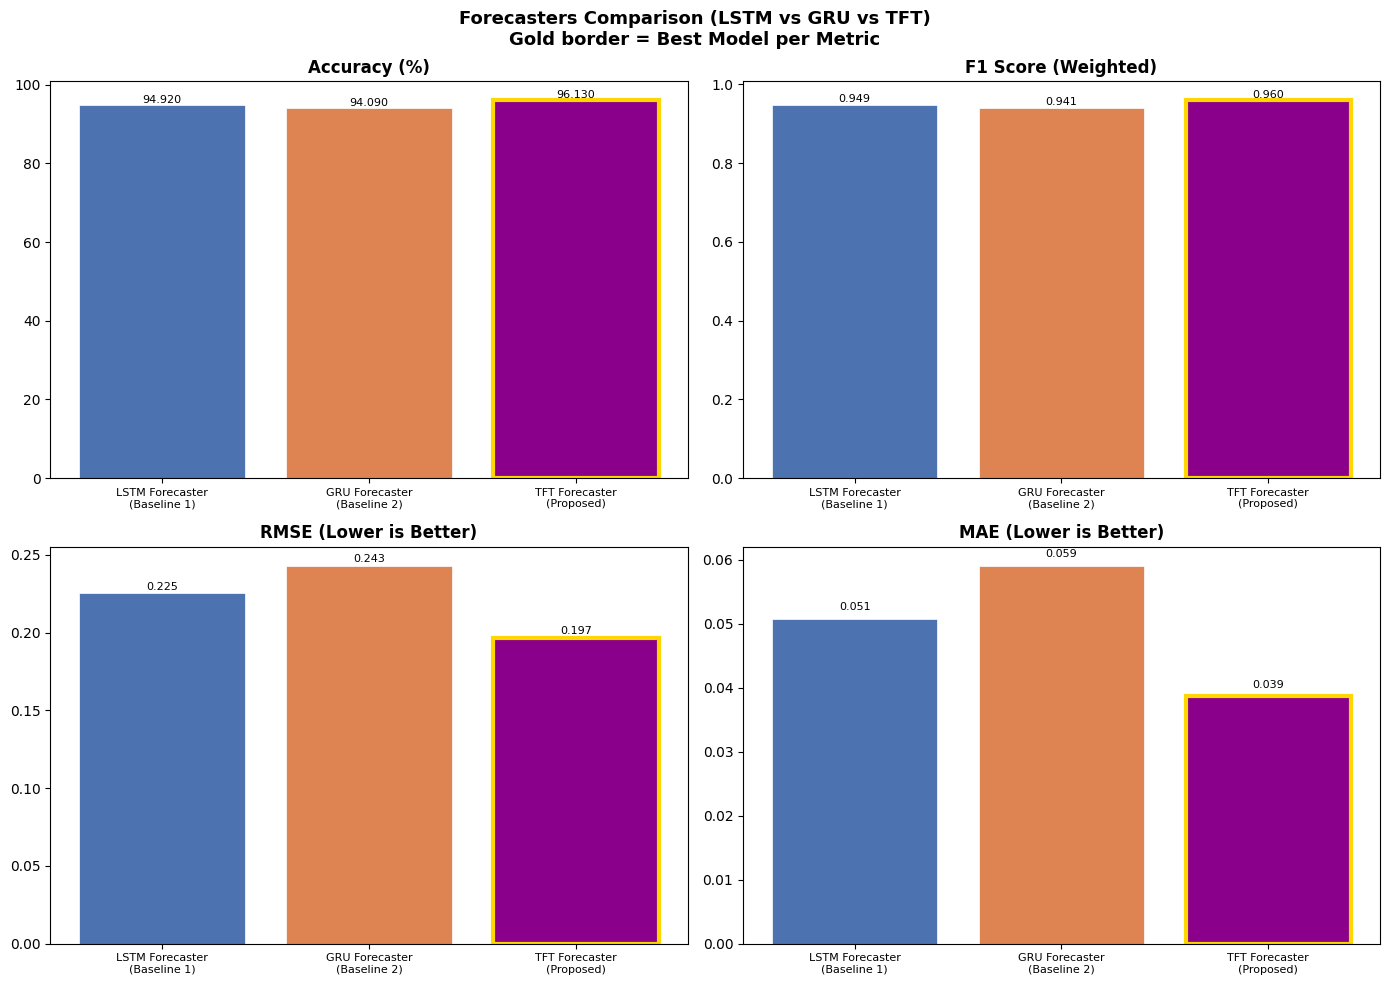

✅ Forecasters-only chart saved.


In [6]:
forecaster_labels = [
    'LSTM Forecaster (Baseline 1)',
    'GRU Forecaster (Baseline 2)',
    'TFT Forecaster (Proposed)',
]
fc_df = display_df[display_df['Model'].isin(forecaster_labels)].reset_index(drop=True)
fc_colors = ['#4C72B0', '#DD8452', '#8B008B']
x_fc = np.arange(len(fc_df))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col, title, higher_better) in zip(axes.flat, metrics):
    vals = fc_df[col].values
    bars = ax.bar(x_fc, vals, color=fc_colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x_fc)
    ax.set_xticklabels([m.replace(' (', '\n(') for m in fc_df['Model']], fontsize=8)
    ax.set_title(title, fontweight='bold')
    best = np.argmax(vals) if higher_better else np.argmin(vals)
    bars[best].set_edgecolor('gold')
    bars[best].set_linewidth(3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Forecasters Comparison (LSTM vs GRU vs TFT)\nGold border = Best Model per Metric',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('forecast_comparison_forecasters_only.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Forecasters-only chart saved.')


In [7]:
display_df.to_csv('forecast_comparison_results.csv', index=False)
print('✅ Results saved to forecast_comparison_results.csv')


✅ Results saved to forecast_comparison_results.csv
